/home/yannis/anaconda3/lib/python3.13/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


Heatmap generado con éxito: Heatmap_Salmonella_Final.pdf


<Figure size 1500x8000 with 0 Axes>

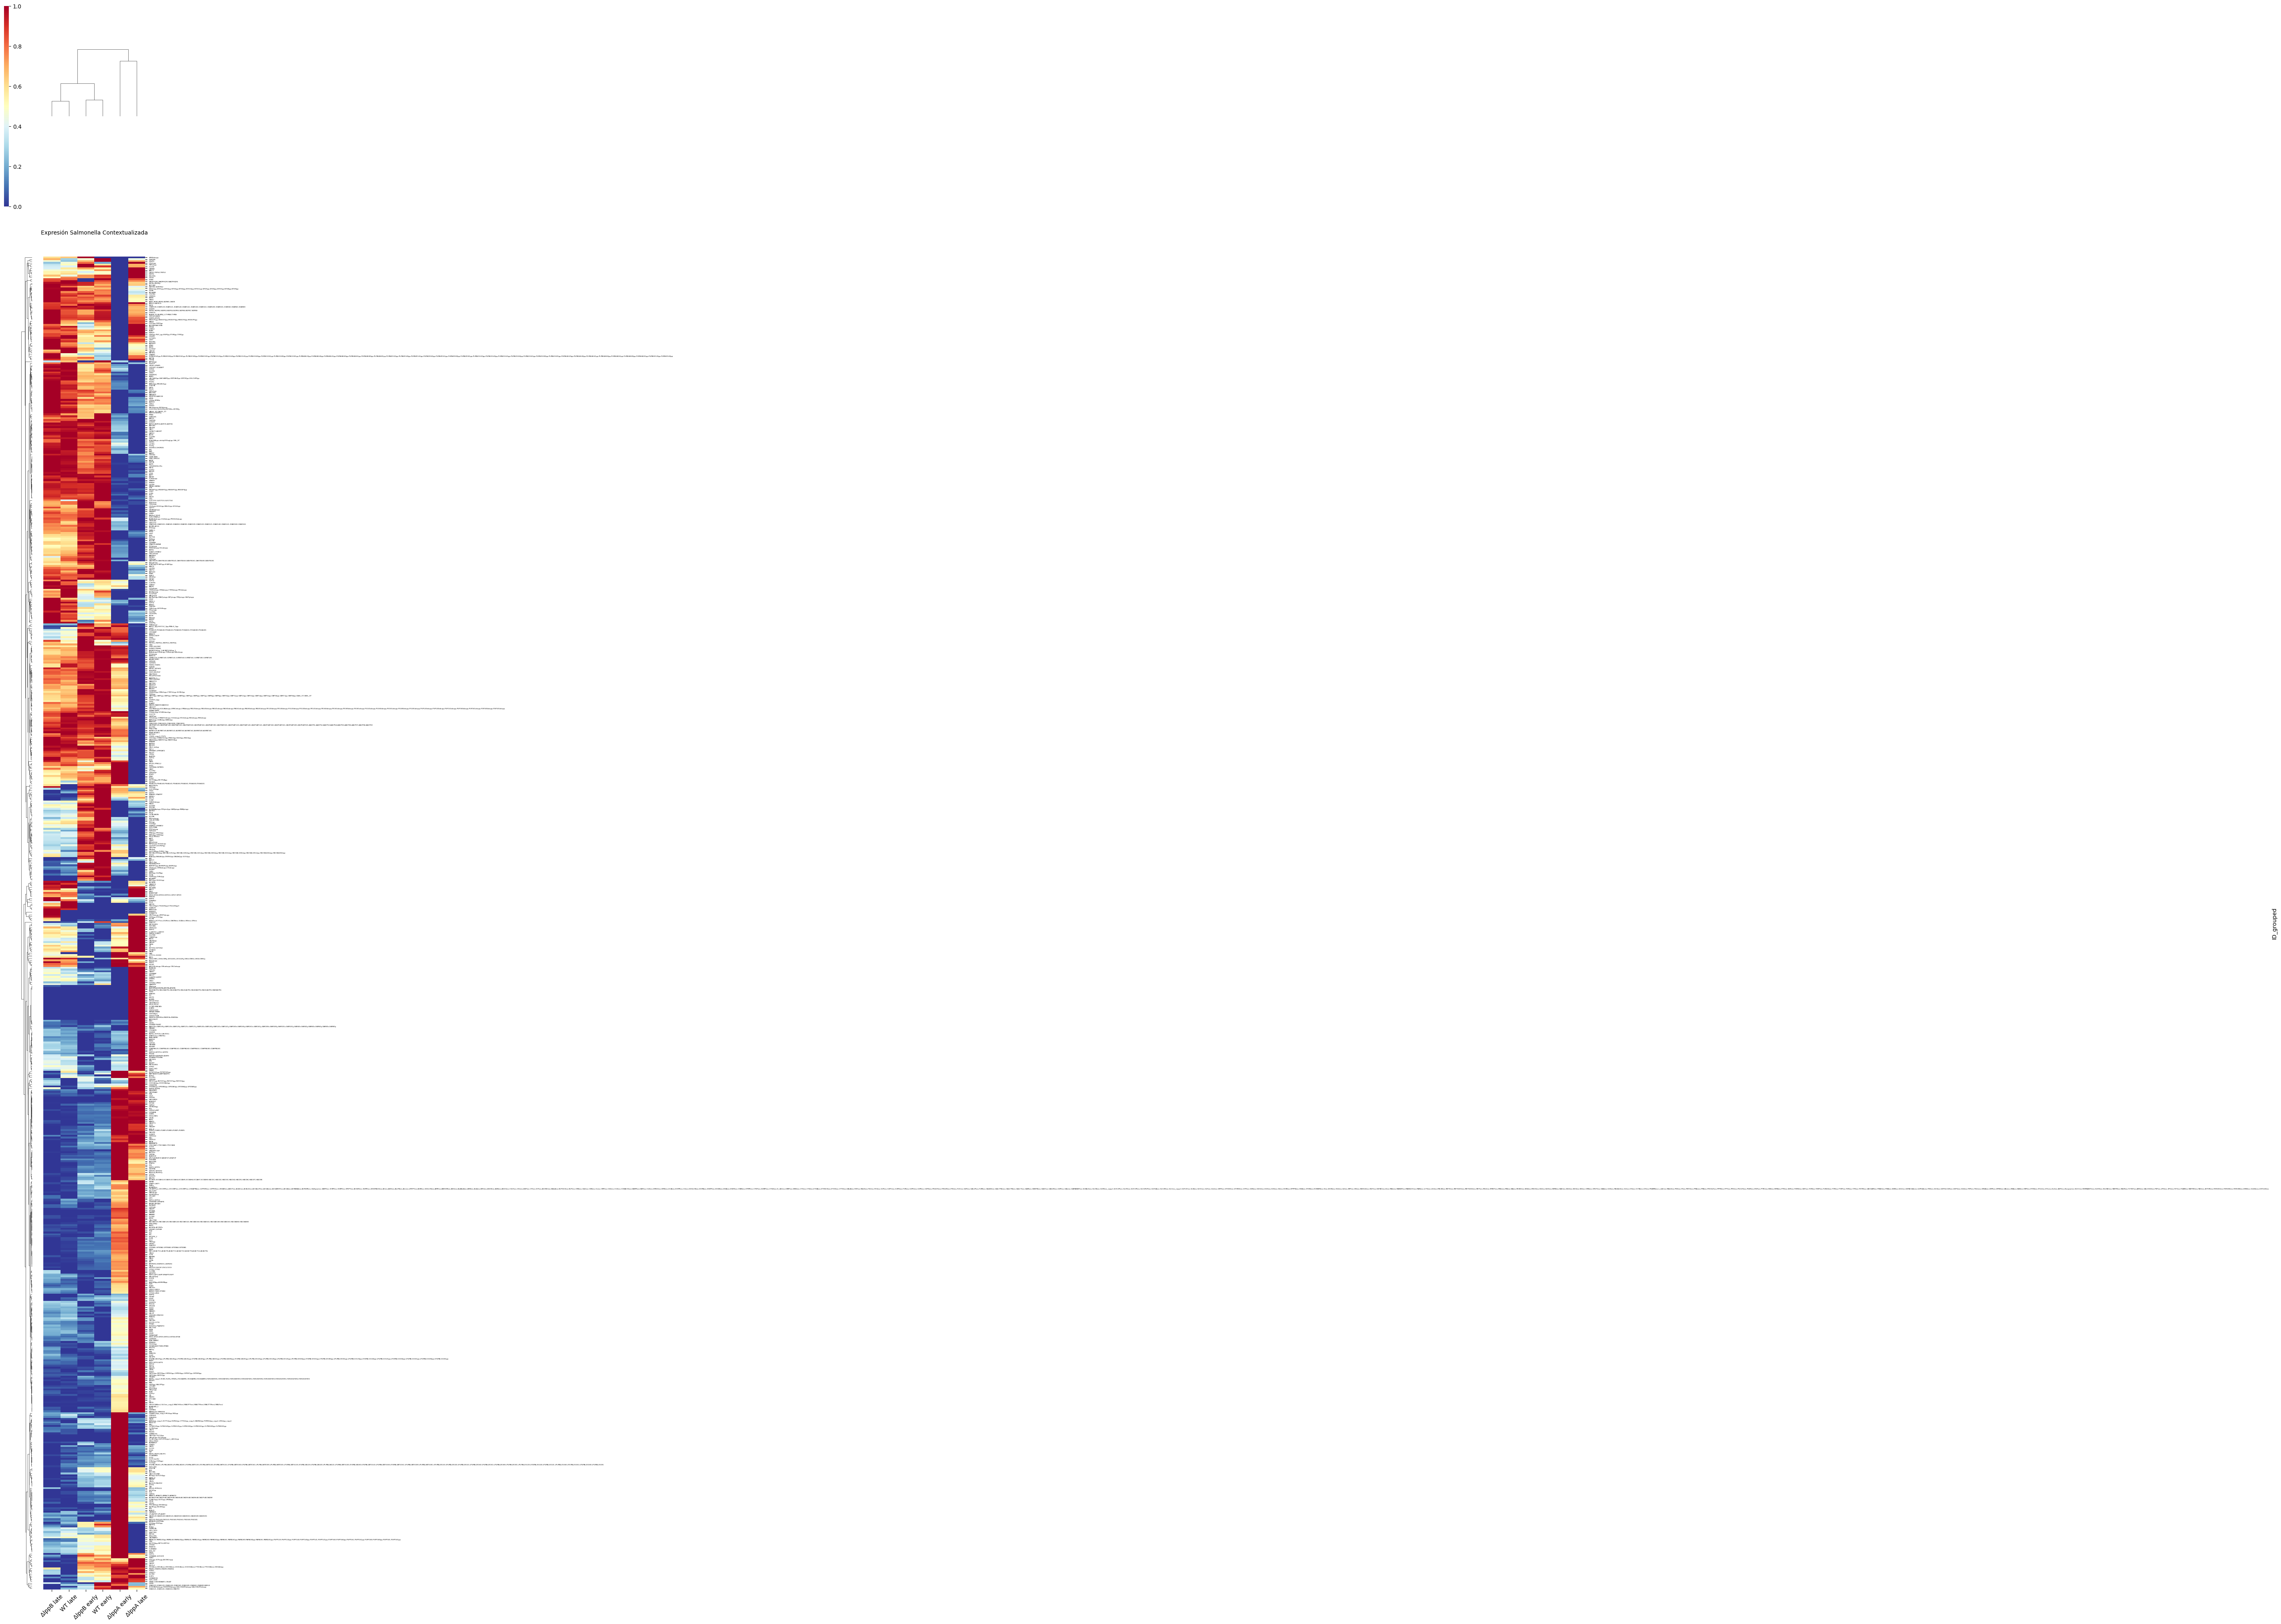

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN E IMPORTACIÓN
file_path = "salmonella_reactions_cutoffespecificos.xlsx"

# Leer los datos
df = pd.read_excel(file_path)

# Identificamos las columnas de condiciones (de la 2 a la 7)
# En Python los índices empiezan en 0, así que columnas 2-7 son índices 1:7
cond_cols = list(df.columns[1:7])
id_col = df.columns[0] # Normalmente "ID"

# Convertir a numérico, transformando "KO" o errores en 0
df[cond_cols] = df[cond_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. FILTRADO
# 2.1 Reacciones con expresión > 0 en al menos una condición
df_filtered = df[(df[cond_cols] > 0).any(axis=1)].copy()

# 2.2 Reacciones con desviación estándar > 0.5
df_filtered_sd = df_filtered[df_filtered[cond_cols].std(axis=1) > 0.5].copy()

# 3. AGRUPACIÓN CON REDONDEO Y CONCATENACIÓN
# Creamos columnas temporales de redondeo para agrupar perfiles similares
temp_cols = [f"temp_{col}" for col in cond_cols]
for col in cond_cols:
    df_filtered_sd[f"temp_{col}"] = df_filtered_sd[col].round(2)

# Agrupación robusta para evitar el KeyError
df_grouped = df_filtered_sd.groupby(temp_cols).agg(
    ID_grouped=(id_col, lambda x: '-'.join(x.astype(str))),
    **{col: (col, 'mean') for col in cond_cols}
).reset_index()

# Establecemos los IDs concatenados como índice para el heatmap
mat_data = df_grouped.set_index('ID_grouped')[cond_cols]

# 4. NORMALIZACIÓN (Min-Max por fila)
mat_normalized = mat_data.apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else x * 0, 
    axis=1
)

# 5. GENERACIÓN DEL HEATMAP (CLUSTERMAP)
# figsize: (Ancho, Alto). 
# Un ancho pequeño (12-15) hace las columnas estrechas en un PDF de gran altura (60-80).
plt.figure(figsize=(15, 80))

g = sns.clustermap(
    mat_normalized,
    cmap="RdYlBu_r",        # Paleta Red-Yellow-Blue invertida
    standard_scale=None,
    row_cluster=True,
    col_cluster=True,
    figsize=(4, 50),       # Proporción: Estrecho y muy largo
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.05), # Reduce el tamaño de los "pelitos" del dendrograma
    cbar_pos=(0.02, 0.8, 0.03, 0.1)
)

# AJUSTES DE FUENTE (Letras grandes)
# xticks = Columnas, yticks = Filas (IDs)
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=10, rotation=45) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=3) # Letras de los IDs grandes

# Título
g.ax_heatmap.set_title("Expresión Salmonella Contextualizada", fontsize=10, pad=40)

# Guardar en PDF con alta calidad
plt.savefig("Heatmap_Salmonella_Final.pdf", bbox_inches='tight', dpi=300)

print("Heatmap generado con éxito: Heatmap_Salmonella_Final.pdf")
plt.show()